# Potential Problems in Linear Regression

Linear regression is a common and powerful tool for investigating relationships between predictors and outcomes. However, there are many issues that can arise when trying to fit a linear model. In this document, we will cover three common issues:

- Outliers
- High-Leverage Points
- Collinearity

We will cover what these issues are and if there are possible solutions, and visualize them in code.

## Outliers
Outliers are data that fall significantly far from the predicted `y` from the model. They can arise from various reasons including sampling error, observation error, or natural variability. The issue with outliers arise when considering the interpretation of the model fit. Sometimes the inclusion of an outlier can cause a dramatic increase or decrease in metrics such as the confidence intervals and p-values, which are used directly to interpret relationships and examine model fit.

We can detect outliers by examing residual plots. An outlier should be clearly visible in a residual plot, falling far outside of the regression line. If this is not the case, however, there still may be residuals present. We can also visualize by plotting the studentized residuals, which is the residual divided by its estimated standard error. An absolute value studentized residual greater than 3 is considered a possible outlier. 

There are a few solutions if outliers are present. We can simply remove the data if we assume it is from a sampling or observation error. However, we should take caution as the outlier may be a legitimate pattern in the data and could indicate a deficiency in the model, like a missing predictor.

*Question*: How would you know if your outliers are simply errors, or if they are a legitimate pattern in the data?

Upon some reading, the statistics community seems to have many different answers and opinions to this. Ultimately, the decision to include or exclude a data point is fairly subjective, but there are many mathematical methods to help determine if data are falling far from the expected range. Some methods require assumptions about data, like normalcy, as non-normal data can have far larger rates of data that appear as outliers. Many methods, such as Mahalanobis distance, k-nearest neighbors or anomoly detection methods, utilize distance based metrics to define a data point that is far from the others. Ultimately, deciding if a data point is legitimate or not is subjective, based on available metadata, outlier detection methods used, and statistical question being asked.

Below is code created by a Generative AI tool to demonstrate an outlier, the issue with having outliers, and a possible solution. It decided to create a linear relationship modeled with a standard OLS, representing data with and without outliers. Like we mentioned earlier, there are many ways to determine outliers and its all subjective whether they should be removed or not. The AI decided to determine if points are considered outliers or not with a interquartile range (IQR) removal method. Any points falling outside of the defined range (Q1 - 1.5 * IQR (lower bound) and Q3 + 1.5 * IQR (upper bound)) are assigned as outliers and removed.

Panel 1 shows the raw data with the OLS regression for data with and without outliers. Panel 2 shows the residuals of the outlier dataset, clearly showing the outliers outside of the acceptable range. Panel 3 shows the regression lines before and after removal of outliers, and panel 4 shows the final linear regression post-removal of outliers. As we can see, the regression was not changed significantly post removal of outliers, indicating perhaps those outliers were not as important to remove as initially thought. This would be up to a researcher to decide to remove or not based on specific research context.

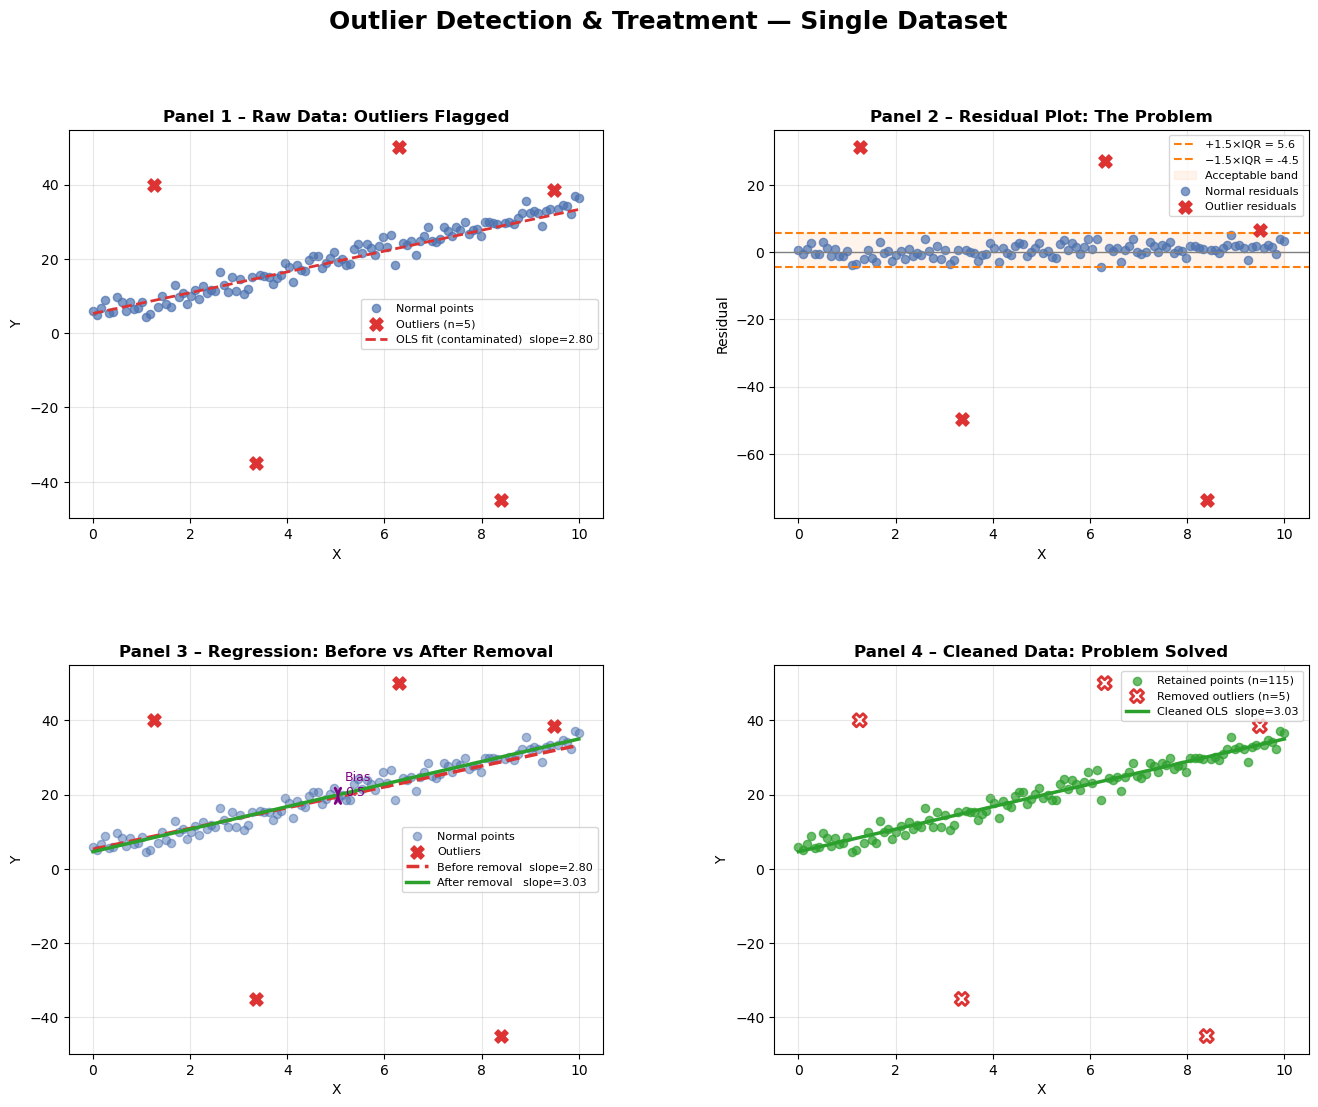


Slope estimates
  Contaminated OLS : 2.8023
  Cleaned OLS      : 3.0339

Outliers removed  : 5 / 120 (4.2%)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)

# ── 1. Synthetic data (one dataset) ──────────────────────────────────────────
n = 120
x = np.linspace(0, 10, n)
y = 3 * x + 5 + np.random.normal(0, 2, n)

# Inject outliers directly into y
outlier_idx = [15, 40, 75, 100]
y[outlier_idx] = np.array([40, -35, 50, -45])

# ── 2. OLS fit on raw (contaminated) data ────────────────────────────────────
def ols(x, y):
    slope, intercept, *_ = stats.linregress(x, y)
    return slope, intercept, slope * x + intercept

slope_raw, int_raw, y_fit_raw = ols(x, y)

# ── 3. Detect outliers via IQR on residuals ───────────────────────────────────
residuals = y - y_fit_raw
Q1, Q3 = np.percentile(residuals, [25, 75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

mask_ok  = (residuals >= lower) & (residuals <= upper)
mask_out = ~mask_ok

# ── 4. Refit on cleaned data ──────────────────────────────────────────────────
x_clean, y_clean = x[mask_ok], y[mask_ok]
slope_clean, int_clean, _ = ols(x_clean, y_clean)
y_fit_clean = slope_clean * x + int_clean   # evaluated over full x for plotting

# ── 5. Figure ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Outlier Detection & Treatment — Single Dataset", fontsize=18, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

BLUE, RED, GREEN, ORANGE = "#4C72B0", "#DD3333", "#2CA02C", "#FF7F0E"

# Panel 1: Raw data with outliers flagged
ax1.scatter(x[mask_ok],  y[mask_ok],  color=BLUE, s=35, alpha=0.7, label="Normal points")
ax1.scatter(x[mask_out], y[mask_out], color=RED,  s=90, zorder=5, marker="X", label=f"Outliers (n={mask_out.sum()})")
ax1.plot(x, y_fit_raw, color=RED, lw=2, linestyle="--", label=f"OLS fit (contaminated)  slope={slope_raw:.2f}")
ax1.set_title("Panel 1 – Raw Data: Outliers Flagged", fontweight="bold")
ax1.set_xlabel("X"); ax1.set_ylabel("Y")
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# Panel 2: Residual plot
ax2.axhline(0,     color="gray",   lw=1)
ax2.axhline(upper, color=ORANGE,   lw=1.5, linestyle="--", label=f"+1.5×IQR = {upper:.1f}")
ax2.axhline(lower, color=ORANGE,   lw=1.5, linestyle="--", label=f"−1.5×IQR = {lower:.1f}")
ax2.fill_between(x, lower, upper,  color=ORANGE, alpha=0.08, label="Acceptable band")
ax2.scatter(x[mask_ok],  residuals[mask_ok],  color=BLUE, s=35, alpha=0.7, label="Normal residuals")
ax2.scatter(x[mask_out], residuals[mask_out], color=RED,  s=90, zorder=5, marker="X", label="Outlier residuals")
ax2.set_title("Panel 2 – Residual Plot: The Problem", fontweight="bold")
ax2.set_xlabel("X"); ax2.set_ylabel("Residual")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Panel 3: Regression before vs after on same data
ax3.scatter(x[mask_ok],  y[mask_ok],  color=BLUE, s=35, alpha=0.5, label="Normal points")
ax3.scatter(x[mask_out], y[mask_out], color=RED,  s=90, zorder=5, marker="X", label="Outliers")
ax3.plot(x, y_fit_raw,   color=RED,   lw=2.5, linestyle="--", label=f"Before removal  slope={slope_raw:.2f}")
ax3.plot(x, y_fit_clean, color=GREEN, lw=2.5,                  label=f"After removal   slope={slope_clean:.2f}")
mid = n // 2
ax3.annotate("", xy=(x[mid], y_fit_clean[mid]), xytext=(x[mid], y_fit_raw[mid]),
             arrowprops=dict(arrowstyle="<->", color="purple", lw=2))
ax3.text(x[mid] + 0.15, (y_fit_clean[mid] + y_fit_raw[mid]) / 2,
         f"Bias\n{abs(y_fit_raw[mid] - y_fit_clean[mid]):.1f}", color="purple", fontsize=9)
ax3.set_title("Panel 3 – Regression: Before vs After Removal", fontweight="bold")
ax3.set_xlabel("X"); ax3.set_ylabel("Y")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# Panel 4: Cleaned data only
ax4.scatter(x_clean, y_clean,       color=GREEN, s=35, alpha=0.7, label=f"Retained points (n={mask_ok.sum()})")
ax4.scatter(x[mask_out], y[mask_out], color=RED, s=90, zorder=5, marker="X",
            facecolors="none", linewidths=2, label=f"Removed outliers (n={mask_out.sum()})")
ax4.plot(x, y_fit_clean, color=GREEN, lw=2.5, label=f"Cleaned OLS  slope={slope_clean:.2f}")
ax4.set_title("Panel 4 – Cleaned Data: Problem Solved", fontweight="bold")
ax4.set_xlabel("X"); ax4.set_ylabel("Y")
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

plt.show()

print(f"\nSlope estimates")
print(f"  Contaminated OLS : {slope_raw:.4f}")
print(f"  Cleaned OLS      : {slope_clean:.4f}")
print(f"\nOutliers removed  : {mask_out.sum()} / {n} ({100*mask_out.sum()/n:.1f}%)")

## High-Leverage Points

Unlike outliers which are observation in y that are inconsistent, high-leverage points are data that are inconsistent in the predictor x. While we saw that removing outliers made little change on regression coefficients, high-leverage observations tend to have a much larger impact and if a regression is highly impacted by these few observations, it can invalidate the entire model's fit.

We can identify high leverage points by observing points that fall outside of the normal range of all observations. For multiple linear regressions, we must look at observations that are unusual in terms of all predictors. We can calculate a *leverage statistic*, a metric that encompasses how far an observation's predictor is from all other predictor values. A leverage statistic greater than the average leverage of all observations could be a potential high leverage point.

*Question*: When is an observation high-leverage vs simply a very influential observations? When to remove vs keep an observation?

Upon some reading, and similar to outliers, the statistics community remains split about removing data based on influence. There are a few considerations to be made before any removal:

- Is the high leverage point ALSO an outlier?
- How do the residuals fall?
- Does removal significantly influence model estimates?
- Are there data quality or measurement issues?

It is generally considered appropriate to remove a high leverage point if it is clearly an error, or perhaps if it is not representative of the population and is determined to influence the model meaningfully. It is appropriate to keep the observation if removal does not influence model estimates, or if the extreme value is determined to be legitimate. Once again, it is subjective but proper investigation should be made before proceeding with analyzing model estimates.

The code below was created by generative AI to visualize an extreme example of a high leverage point using synthetic data with one predictor. In panel 1 (top left), we can see the linear regression for the raw data with and without the inclusion of a high leverage point. We can see the regression changes significantly with the removal of the high leverage point. The other plots show different verification methods to assess whether a point is high leverage or not. The hat matrix shows whether a point is outlying with regards to X values. Any point above the arbitrary threshold of (2 * parameters / total number of observations) is flagged high leverage. Cook's distance measures the influence of a removing a data point on the model. Finally, we see a plot of every data point's leverage against its residual. We can see our high leverage point is both high in leverage and has an abnormal residual, indicating it likely has a large influence on our regression.

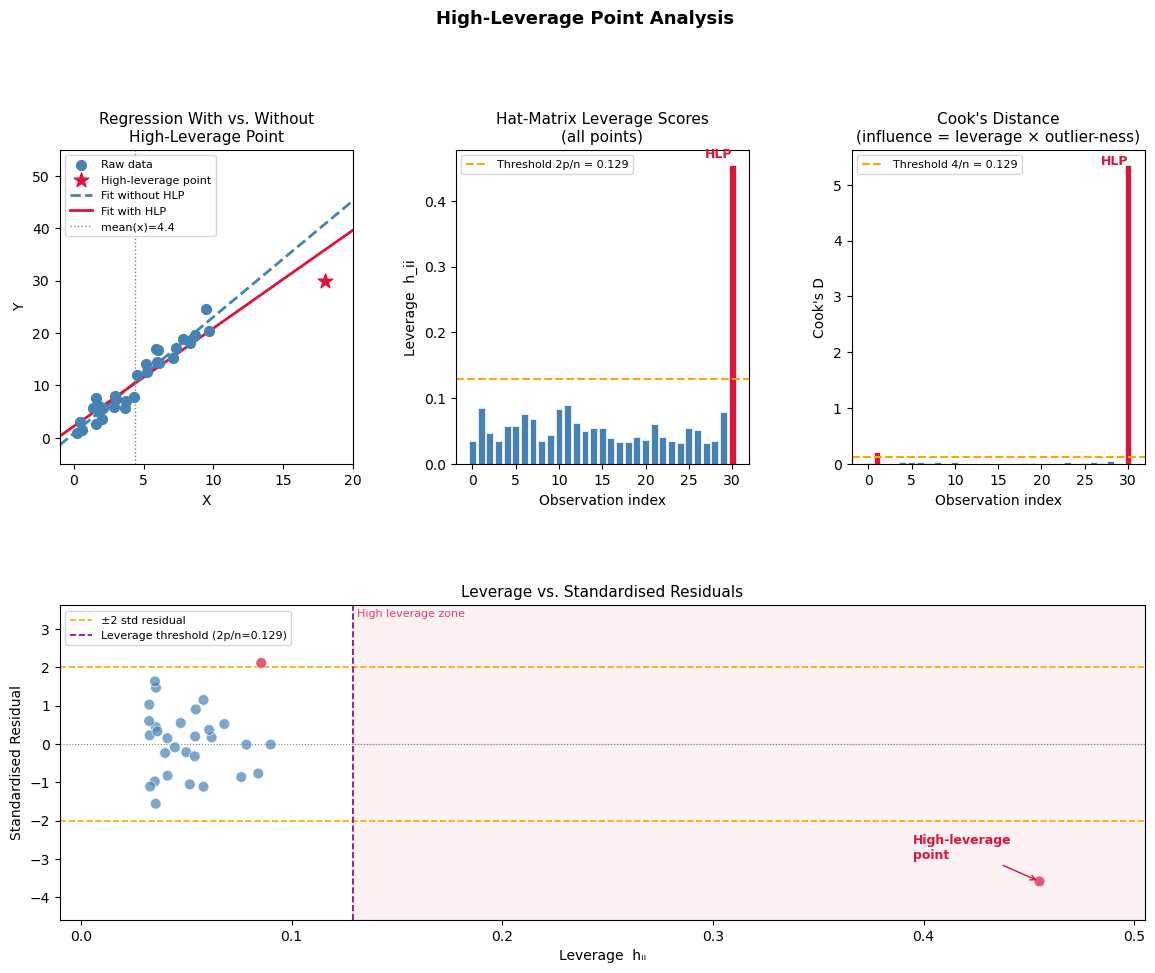


Slope without HLP : 2.221
Slope with    HLP : 1.874
Change in slope   : 0.348

Leverage of HLP   : 0.4549  (threshold = 0.1290)
Cook's D of HLP   : 5.3605  (threshold = 0.1290)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# --- Generate base data ---
n = 30
x = np.random.uniform(0, 10, n)
y = 2.5 * x + np.random.normal(0, 2, n)

# --- High-leverage point: far from mean(x), pulls the regression line ---
hlp_x = np.array([18.0])   # extreme X value (far from cloud)
hlp_y = np.array([30.0])   # low Y relative to the trend → exerts high leverage

x_all = np.append(x, hlp_x)
y_all = np.append(y, hlp_y)

# --- Fit two models ---
def fit(x, y):
    reg = LinearRegression().fit(x.reshape(-1,1), y)
    return reg.coef_[0], reg.intercept_

slope_without, intercept_without = fit(x, y)
slope_with,    intercept_with    = fit(x_all, y_all)

# --- Hat matrix leverage scores ---
def leverage(x):
    X = np.column_stack([np.ones_like(x), x])
    H = X @ np.linalg.inv(X.T @ X) @ X.T
    return np.diag(H)

h_without = leverage(x)
h_with    = leverage(x_all)
threshold = 2 * 2 / len(x_all)   # 2p/n rule of thumb

# --- Plot ---
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, wspace=0.35, hspace=0.45)

x_line = np.linspace(-1, 20, 300)

# ── Panel 1: scatter + regression lines ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(x, y, color="steelblue", s=50, zorder=3, label="Raw data")
ax1.scatter(hlp_x, hlp_y, color="crimson", s=120, zorder=4,
            marker="*", label="High-leverage point")

ax1.plot(x_line, slope_without * x_line + intercept_without,
         "steelblue", lw=2, linestyle="--", label="Fit without HLP")
ax1.plot(x_line, slope_with * x_line + intercept_with,
         "crimson",   lw=2, linestyle="-",  label="Fit with HLP")

ax1.axvline(x.mean(), color="gray", lw=1, linestyle=":", label=f"mean(x)={x.mean():.1f}")
ax1.set_xlim(-1, 20); ax1.set_ylim(-5, 55)
ax1.set_title("Regression With vs. Without\nHigh-Leverage Point", fontsize=11)
ax1.set_xlabel("X"); ax1.set_ylabel("Y")
ax1.legend(fontsize=8, loc="upper left")

# ── Panel 2: leverage scores (with HLP) ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
colors = ["crimson" if hi > threshold else "steelblue" for hi in h_with]
ax2.bar(range(len(h_with)), h_with, color=colors, edgecolor="white", linewidth=0.5)
ax2.axhline(threshold, color="orange", lw=1.5, linestyle="--",
            label=f"Threshold 2p/n = {threshold:.3f}")
ax2.set_title("Hat-Matrix Leverage Scores\n(all points)", fontsize=11)
ax2.set_xlabel("Observation index"); ax2.set_ylabel("Leverage  h_ii")
ax2.legend(fontsize=8)
ax2.text(len(h_with)-1, h_with[-1]+0.01, "HLP", color="crimson",
         ha="right", fontsize=9, fontweight="bold")

# ── Panel 3: Cook's distance ──────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression

def cooks_distance(x, y):
    n, p = len(x), 2
    X  = np.column_stack([np.ones(n), x])
    b  = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ b
    res   = y - y_hat
    mse   = np.sum(res**2) / (n - p)
    H     = X @ np.linalg.inv(X.T @ X) @ X.T
    h     = np.diag(H)
    D     = (res**2 * h) / (p * mse * (1 - h)**2)
    return D

D = cooks_distance(x_all, y_all)
cook_thresh = 4 / len(x_all)
colors_c = ["crimson" if d > cook_thresh else "steelblue" for d in D]

ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(range(len(D)), D, color=colors_c, edgecolor="white", linewidth=0.5)
ax3.axhline(cook_thresh, color="orange", lw=1.5, linestyle="--",
            label=f"Threshold 4/n = {cook_thresh:.3f}")
ax3.set_title("Cook's Distance\n(influence = leverage × outlier-ness)", fontsize=11)
ax3.set_xlabel("Observation index"); ax3.set_ylabel("Cook's D")
ax3.legend(fontsize=8)
ax3.text(len(D)-1, D[-1]+0.002, "HLP", color="crimson",
         ha="right", fontsize=9, fontweight="bold")

# ── Panel 4: Leverage vs Residuals ───────────────────────
X_mat = np.column_stack([np.ones_like(x_all), x_all])
b_all = np.linalg.lstsq(X_mat, y_all, rcond=None)[0]
raw_resid = y_all - X_mat @ b_all
mse_all   = np.sum(raw_resid**2) / (len(x_all) - 2)
std_resid = raw_resid / np.sqrt(mse_all * (1 - h_with))   # standardised residuals

ax4 = fig.add_subplot(gs[1, :])   # full-width bottom row spanning all 3 cols
colors_lr = ["crimson" if d > cook_thresh else "steelblue" for d in D]

sc = ax4.scatter(h_with, std_resid,
                 s=60,
                 c=colors_lr, alpha=0.7, edgecolors="white", linewidth=0.6, zorder=3)

# Reference lines
ax4.axhline( 2, color="orange", lw=1.2, linestyle="--", label="±2 std residual")
ax4.axhline(-2, color="orange", lw=1.2, linestyle="--")
ax4.axhline( 0, color="gray",   lw=0.8, linestyle=":")
ax4.axvline(threshold, color="purple", lw=1.2, linestyle="--",
            label=f"Leverage threshold (2p/n={threshold:.3f})")

# Annotate the HLP
ax4.annotate("High-leverage\npoint",
             xy=(h_with[-1], std_resid[-1]),
             xytext=(h_with[-1] - 0.06, std_resid[-1] + 0.6),
             arrowprops=dict(arrowstyle="->", color="crimson"),
             color="crimson", fontsize=9, fontweight="bold")

# Shade the four quadrants lightly
xlim = ax4.get_xlim() if ax4.get_xlim()[1] > h_with[-1]+0.02 else (0, h_with[-1]+0.05)
ax4.set_xlim(-0.01, h_with[-1] + 0.05)
ax4.set_ylim(min(std_resid) - 1, max(std_resid) + 1.5)
xl, xr = ax4.get_xlim(); yb, yt = ax4.get_ylim()
ax4.fill_betweenx([0, yt], threshold, xr, alpha=0.06, color="crimson")   # high lev, pos resid
ax4.fill_betweenx([yb, 0], threshold, xr, alpha=0.06, color="crimson")   # high lev, neg resid
ax4.text(threshold + 0.002, yt - 0.3, "High leverage zone", color="crimson",
         fontsize=8, alpha=0.8)

ax4.set_title("Leverage vs. Standardised Residuals", fontsize=11)
ax4.set_xlabel("Leverage  hᵢᵢ")
ax4.set_ylabel("Standardised Residual")
ax4.legend(fontsize=8, loc="upper left")

fig.suptitle("High-Leverage Point Analysis", fontsize=13, fontweight="bold", y=1.02)

plt.show()
print(f"\nSlope without HLP : {slope_without:.3f}")
print(f"Slope with    HLP : {slope_with:.3f}")
print(f"Change in slope   : {abs(slope_with - slope_without):.3f}")
print(f"\nLeverage of HLP   : {h_with[-1]:.4f}  (threshold = {threshold:.4f})")
print(f"Cook's D of HLP   : {D[-1]:.4f}  (threshold = {cook_thresh:.4f})")

## Collinearity

Collinearity occures when two or more predictor variables have a discernable relationship. This can cause an issue when trying to interpret model estimates as we cannot separate individual effects of collinear variables. If two variables are collinear, they likely affect the response similarly and thus we cannot discern individual relationships between predictors and response.

We can determine if variables are collinear by either plotting variables against each other and visually examining trends, or looking at a correlation matrix of all predictors. A large value indicated highly correlated variables. If there are perhaps 3 or more variables correlated, however, that will not show in a correlation matrix. We can then look at the variance inflation factor (VIF), the variance of one variables coefficient when fitting the full model divided by the variance of the fit on its own. A VIF larger than 5 or 10 is problematic.

To fix this issue, we can simply remove one of the correlated variables, as collinear variables are likely providing the redundant information to the regression. We can also combine collinear variables into a single predictor, as once again they are providing redundant information on their own.

*Question*: Would you ever want to keep in variables that are collinear? What would happen?

There actually seem to be many different options for what to do when you have correlated variables.

- Do nothing: If our goal is prediction, not interpretation. If collinear variables are controls, and R^2 is not affected.
- Combine variables: If variables conceptually are the same and we don't need to separate effects.
- Drop one variable: One variable is clearly redundant, result's sensitivity analysis is robust. But beware of omitted variable bias.
- Ridge regression: Adds penalty to coefficients and stabilized collinearity. Biases coefficients to zero but predictions can improve.
- Get more data: Reduces variance which can help collinearity issues, but does not help if collinearity is inherent.

It seems like collinearity is less of an issue with predictions, dummy variables, interactive terms, and polynomial terms. Ultimately, it is important to acknowledge collinearity when interpreting and critically assess metrics such as VIF, keeping in mind ommitted variable bias before adjusting variables.

The code below was created by generative AI to simulate collinearity between two variables in multivariate linear regression. The top left plot shows the correlation matrix between all variables, where it is clear gdp and income are correlated. Looking at our VIF on the top right, we can see all variables are below 5 except for GDP and income, which are well above 10 and thus are labeled for further investigation into collinearity. In the bottom left, we can see our collinear variables plotted against each other, and they very clearly have a linear relationship with each other. Finally, while there are many methods to handling collinearity, we examined the effect of removing only one variable (GDP) on model estimates. We can see the estimate for income gets larger, taking on the redundant effect gdp was having on our outcome, and all other variables remain relatively unchanged.

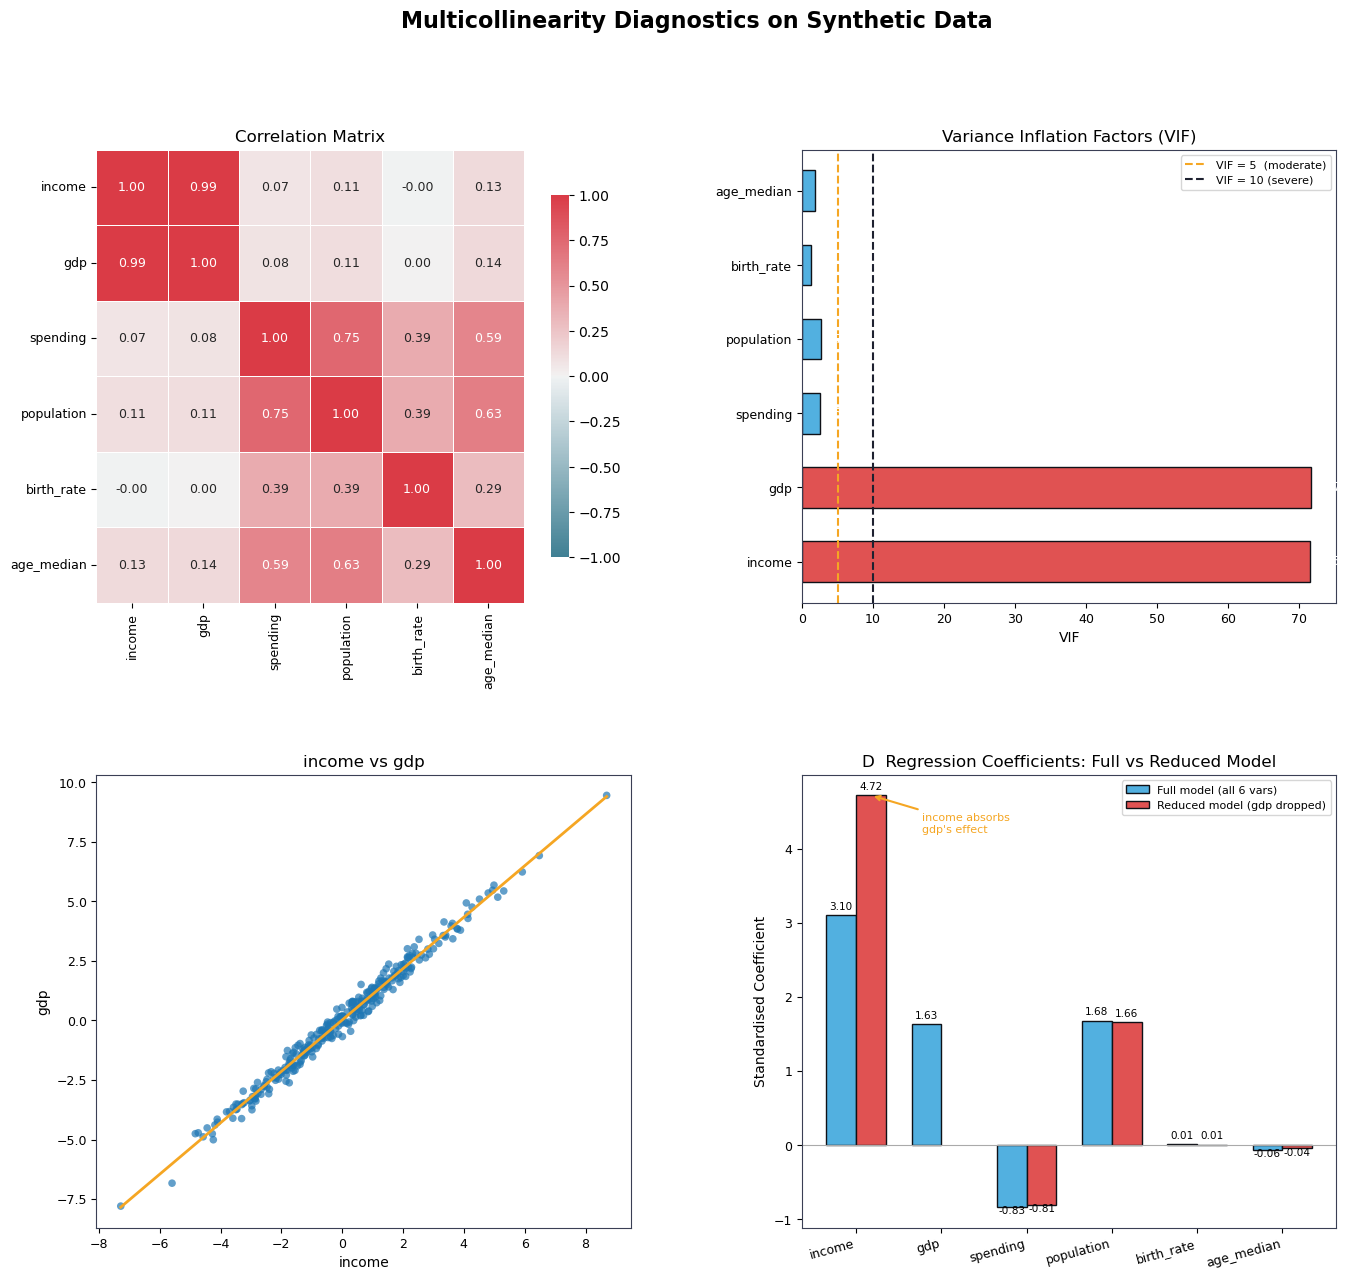


VIF Summary:
income        71.529405
gdp           71.654463
spending       2.506868
population     2.722737
birth_rate     1.211991
age_median     1.766578

Regression Coefficients (standardised):
Variable       Full model  Reduced model
----------------------------------------
income              3.100          4.718
gdp                 1.632            nan
spending           -0.834         -0.809
population          1.678          1.656
birth_rate          0.011          0.009
age_median         -0.057         -0.041


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# ── 1. Generate synthetic collinear data ────────────────────────────────────
np.random.seed(42)
n = 300

# Single shared factor driving only income and gdp
economy = np.random.normal(0, 1, n)

# income and gdp are nearly identical (high VIF)
income     = 2.3 * economy + 0.2 * np.random.normal(0, 1, n)
gdp        = 2.5 * economy + 0.2 * np.random.normal(0, 1, n)

# Other features: mild correlations with each other (VIF between 1 and 5)
base        = np.random.normal(0, 1, n)
spending    = 1.5 * base + 0.84 * np.random.normal(0, 1, n)
population  = 1.5 * base + 0.87 * np.random.normal(0, 1, n)
birth_rate  = 0.45 * base + 0.89 * np.random.normal(0, 1, n)
age_median  = 0.45 * base + 0.50 * np.random.normal(0, 1, n)

# Target (linear combination + noise)
y = 1.2*income + 0.8*gdp - 0.5*spending + 0.9*population + np.random.normal(0, 1, n)

df = pd.DataFrame({
    "income":     income,
    "gdp":        gdp,
    "spending":   spending,
    "population": population,
    "birth_rate": birth_rate,
    "age_median": age_median,
    "y":          y,
})

features = ["income", "gdp", "spending", "population", "birth_rate", "age_median"]

# ── 2. Compute Variance Inflation Factors (VIF) ──────────────────────────────
from numpy.linalg import inv

def compute_vif(X: pd.DataFrame) -> pd.Series:
    Xs = StandardScaler().fit_transform(X)
    corr = np.corrcoef(Xs.T)
    vif  = np.diag(inv(corr))
    return pd.Series(vif, index=X.columns)

vif = compute_vif(df[features])

# ── 3. Plot ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))

gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

ax_title = dict(fontsize=13, fontweight="bold", pad=12)

# ── Panel A: Correlation heatmap ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
corr_mat = df[features].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)   # keep lower triangle + diag
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(
    corr_mat, ax=ax1, annot=True, fmt=".2f", cmap=cmap,
    vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8},
)
ax1.set_title("Correlation Matrix")
ax1.tick_params(labelsize=9)
ax1.figure.axes[-1]

# ── Panel B: VIF bar chart ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
colors = ["#e05252" if v > 5 else "#52b0e0" for v in vif]
bars   = ax2.barh(vif.index, vif.values, color=colors, edgecolor="#0f1117", height=0.55)
ax2.axvline(5,  color="#f5a623", linewidth=1.5, linestyle="--", label="VIF = 5  (moderate)")
ax2.axvline(10, color="#1e2130", linewidth=1.5, linestyle="--", label="VIF = 10 (severe)")
for bar, val in zip(bars, vif.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", color="white", fontsize=9)
ax2.set_title("Variance Inflation Factors (VIF)")
ax2.set_xlabel("VIF")
ax2.tick_params(labelsize=9)
ax2.spines[:].set_color("#3a3f55")
ax2.legend(fontsize=8, framealpha=0.8)

# ── Panel C: Scatter pairs for the strongly collinear economic cluster ────────
ax3 = fig.add_subplot(gs[1, 0])
sc = ax3.scatter(df["income"], df["gdp"],
                 alpha=0.7, edgecolors="none", s=30)

# Overlay regression line
m, b = np.polyfit(df["income"], df["gdp"], 1)
xs   = np.linspace(df["income"].min(), df["income"].max(), 200)
ax3.plot(xs, m*xs + b, color="#f5a623", linewidth=2)
ax3.set_title("income vs gdp")
ax3.set_xlabel("income"); ax3.set_ylabel("gdp")
ax3.tick_params(labelsize=9)
ax3.spines[:].set_color("#3a3f55")

# ── Panel D: Regression coefficient stability ────────────────────────────────
from sklearn.linear_model import LinearRegression

def fit_coefs(feature_cols):
    X = StandardScaler().fit_transform(df[feature_cols])
    m = LinearRegression().fit(X, y)
    return dict(zip(feature_cols, m.coef_))

full_cols    = features                                      # all 6
reduced_cols = [f for f in features if f != "gdp"]          # drop gdp (collinear with income)

full_coefs    = fit_coefs(full_cols)
reduced_coefs = fit_coefs(reduced_cols)

# Align for side-by-side plotting (full model only has gdp, reduced doesn't)
plot_vars  = features
full_vals  = [full_coefs.get(v, np.nan)    for v in plot_vars]
red_vals   = [reduced_coefs.get(v, np.nan) for v in plot_vars]

x      = np.arange(len(plot_vars))
width  = 0.35

ax4 = fig.add_subplot(gs[1, 1])

b1 = ax4.bar(x - width/2, full_vals,  width, label="Full model (all 6 vars)",
             color="#52b0e0", edgecolor="#0f1117")
b2 = ax4.bar(x + width/2, red_vals,   width, label="Reduced model (gdp dropped)",
             color="#e05252", edgecolor="#0f1117",
             tick_label=plot_vars)

# Annotate bars
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax4.text(bar.get_x() + bar.get_width()/2, h + (0.05 if h >= 0 else -0.12),
                     f"{h:.2f}", ha="center", va="bottom", fontsize=7.5)

ax4.axhline(0, color="#aaaaaa", linewidth=0.8)
ax4.set_title("D  Regression Coefficients: Full vs Reduced Model")
ax4.set_ylabel("Standardised Coefficient")
ax4.set_xticks(x)
ax4.set_xticklabels(plot_vars, rotation=15, ha="right")
ax4.tick_params(labelsize=9)
ax4.spines[:].set_color("#3a3f55")
ax4.legend(fontsize=8, framealpha=0.8)

# Annotate the key shift
ax4.annotate("income absorbs\ngdp's effect",
             xy=(x[0] + width/2, red_vals[0]),
             xytext=(x[0] + width/2 + 0.6, red_vals[0] - 0.5),
             arrowprops=dict(arrowstyle="->", color="#f5a623", lw=1.5),
             color="#f5a623", fontsize=8)

# ── Super-title ──────────────────────────────────────────────────────────────
fig.suptitle("Multicollinearity Diagnostics on Synthetic Data",
             fontsize=16, fontweight="bold", y=0.98)

plt.show()

print("\nVIF Summary:")
print(vif.to_string())
print("\nRegression Coefficients (standardised):")
print(f"{'Variable':<12} {'Full model':>12} {'Reduced model':>14}")
print("-" * 40)
for v in plot_vars:
    fc = full_coefs.get(v, float("nan"))
    rc = reduced_coefs.get(v, float("nan"))
    print(f"{v:<12} {fc:>12.3f} {rc:>14.3f}")

### Generative AI Reflection

I used Claude to generate code for this assignment. This is my first time using AI, and Claude specifically, so it was definitely an interesting experience figuring out how to prompt! There were pros and cons for each issue covered:

Outliers: Beyond small syntax errors, Claude initially created two different datasets to compare data with and without outliers and tried to compare OLS regression slopes to each other. I thought that was misleading, as its technically different data and had to reprompt to use the same dataset but remove outliers directly. 

High-leverage: Claude first created an example that was incredible extreme, and far too unrealistic to get the point. I reprompted to create a more realistic value, and it was then too close to the real data. In the end, I just adjusted the values myself. It presented a few methods I did not know, so I had it explain the code to me. It never created a 4 panel plot like I wanted, but I ended up keeping the orientation as it shows the residuals better.

Collinearity: Claude once again created an example that was too extreme, with almost all variables exhibiting high VIF and collinearity. I had to adjust the prompt to only two specific variables for simplicity. I also had issues with the plotting, and had to reprompt a few times to adjust the plots correctly. I ended up fixing the plot aesthetics myself, as it produced plots that were honestly horrible and not meaningful! It also wanted to provide me with way too many validation methods that were overly complicated for what the data looked like, as it sort of did for the other issues as well. I ended up just removing those. 